In [1]:
import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('../data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

print(f"Loaded df of size {df.shape}")

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5
Loaded df of size (33537, 4)


In [2]:
from scripts.utils import extract_unique_npcis
from scripts.data_filter import filter_dataframe

selected_campaigns = list(range(1, 20))

filtered_df = df.copy()

filtered_df = filter_dataframe(
    df=filtered_df,
    operators=[10],
    include_columns=["pci", "beam_index", "nr_arfcn", "operator_id", "rsrp"],
    campaigns=selected_campaigns,
)

print(f"Filtered df of size {filtered_df.shape}")

unique_npcis = extract_unique_npcis(filtered_df['measurements_matrix'])

print(len(unique_npcis))

Filtered df of size (7975, 4)
249


/Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/scripts/data_filter.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["measurements_matrix"] = df["measurements_matrix"].apply(


In [3]:
from scripts.utils import RF_PARAM_5G
import pandas as pd
from typing import Tuple, Optional


def get_best_beam(mat: pd.DataFrame, rf_param: RF_PARAM_5G) -> Tuple[Optional[Tuple[int, int]], Optional[int]]:
    # Drop rows where rf_param is NaN
    mat = mat.dropna(subset=[rf_param.value])

    # Check if the DataFrame is empty after dropping NaNs
    if mat.empty:
        print("No valid data available after dropping NaN values.")
        return None, None

    # Get the best beams by grouping only by 'pci' and 'operator_id'
    idx = mat.groupby(['pci'])[rf_param.value].idxmax()

    # Use the indices to select the rows with the highest 'rsrq' for each group
    best_beams = mat.loc[idx]

    # Get the best pci
    best_index = best_beams[rf_param.value].idxmax()
    best = best_beams.loc[best_index]

    # Make a tuple of pci, op, and beam (nr_arfcn is removed)
    pci = int(best['pci'])
    beam = int(best['beam_index'])

    return pci, beam


# Assuming filtered_df and RF_PARAM_5G are defined elsewhere
data = []
for _, row in filtered_df.iterrows():
    pci, beam = get_best_beam(row['measurements_matrix'], RF_PARAM_5G.RSRP)
    if pci is not None and beam is not None:
        data.append([row['lat'], row['lng'], pci, beam])

# Convert data into a DataFrame
data_df = pd.DataFrame(data, columns=['lat', 'lng', 'pci', 'beam_index'])


No valid data available after dropping NaN values.
No valid data available after dropping NaN values.
No valid data available after dropping NaN values.
No valid data available after dropping NaN values.


Skipping pci -119
Skipping pci -111


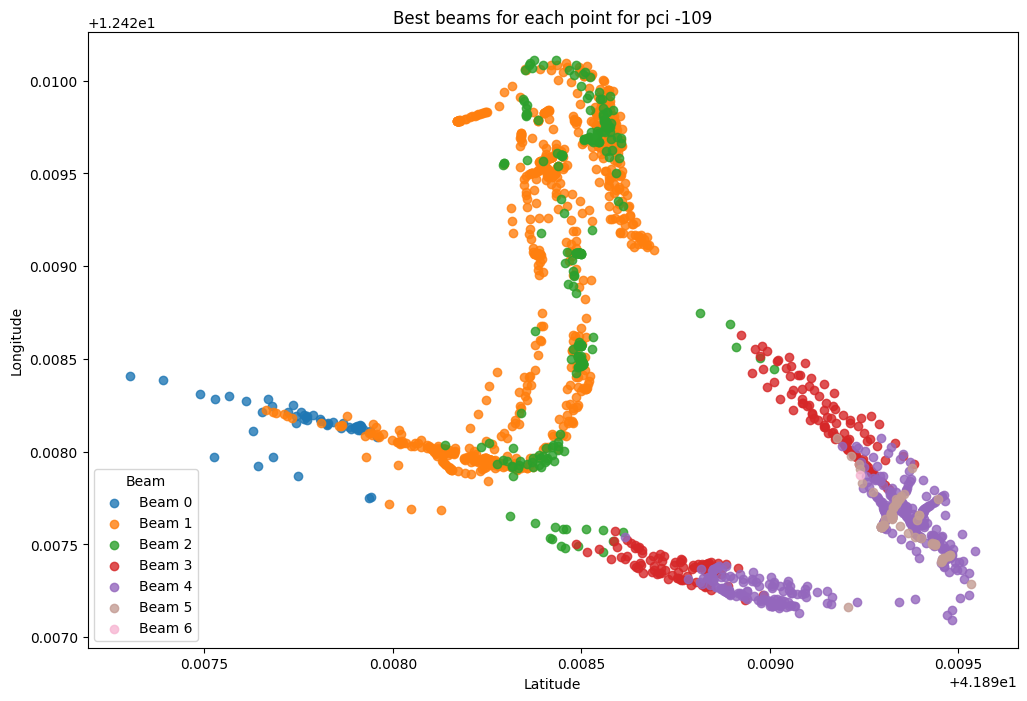

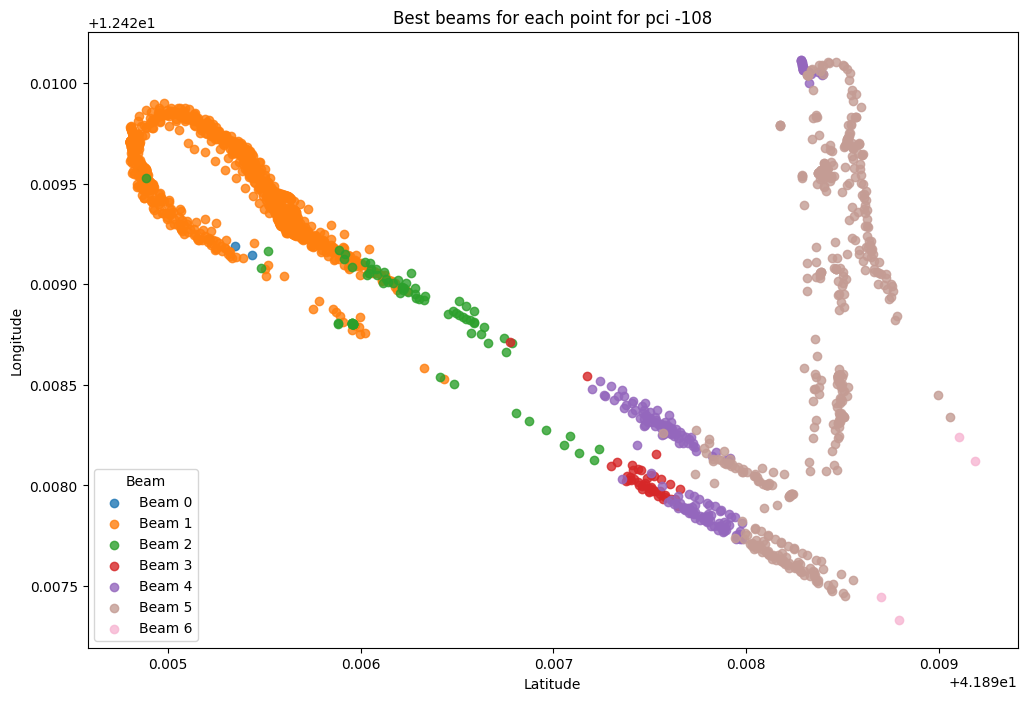

Skipping pci -92


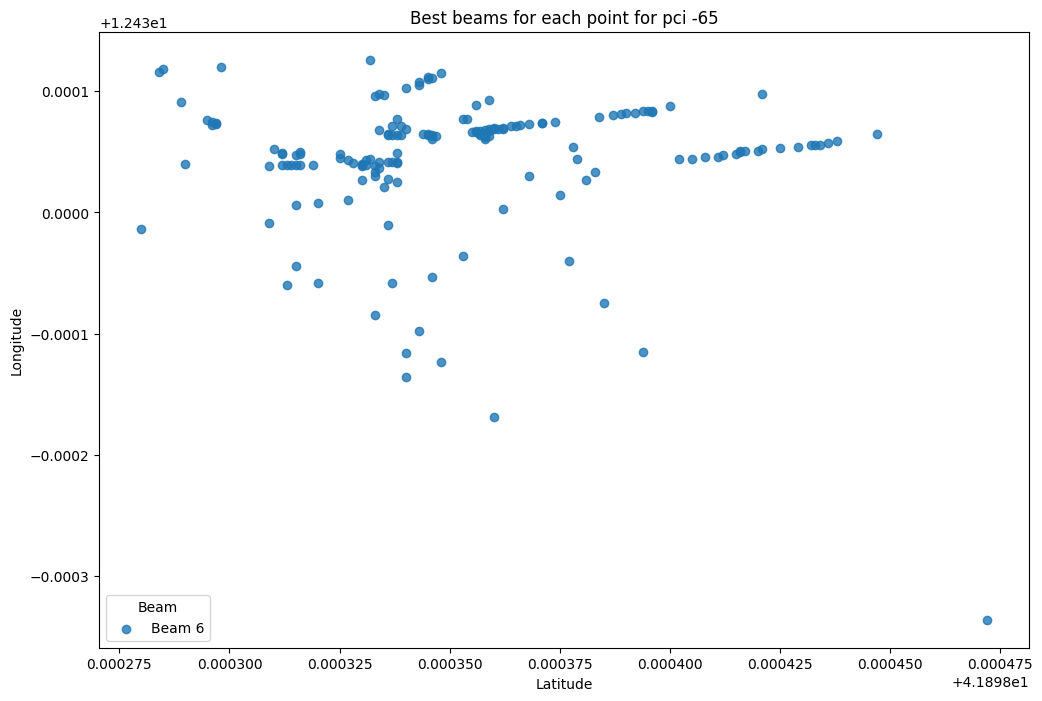

Skipping pci -58
Skipping pci 10


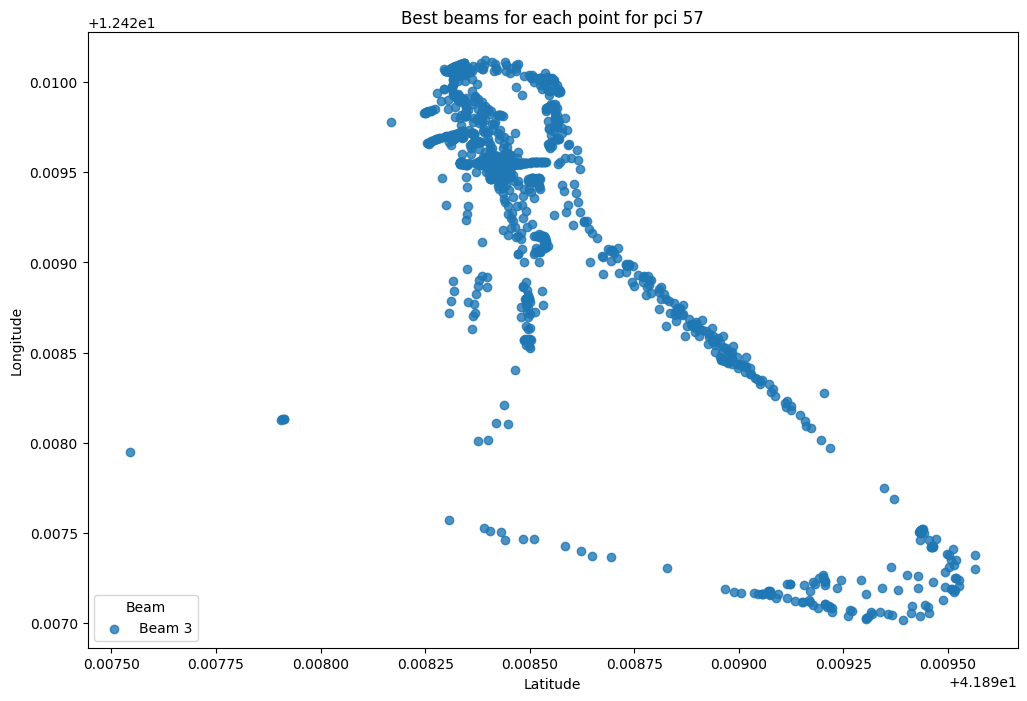

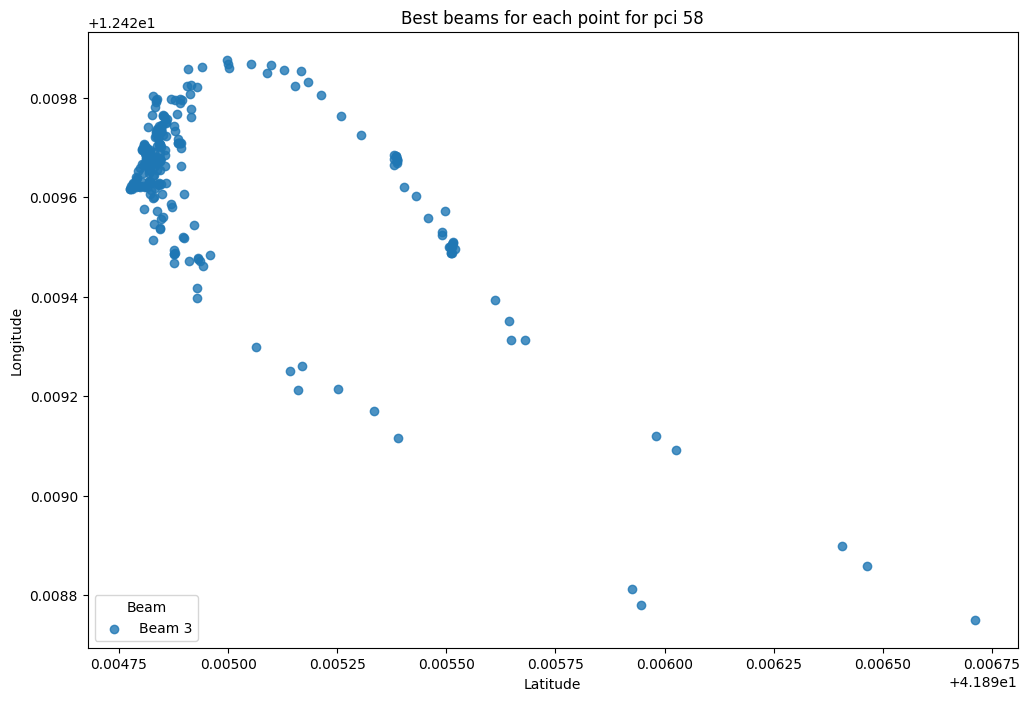

Skipping pci 59


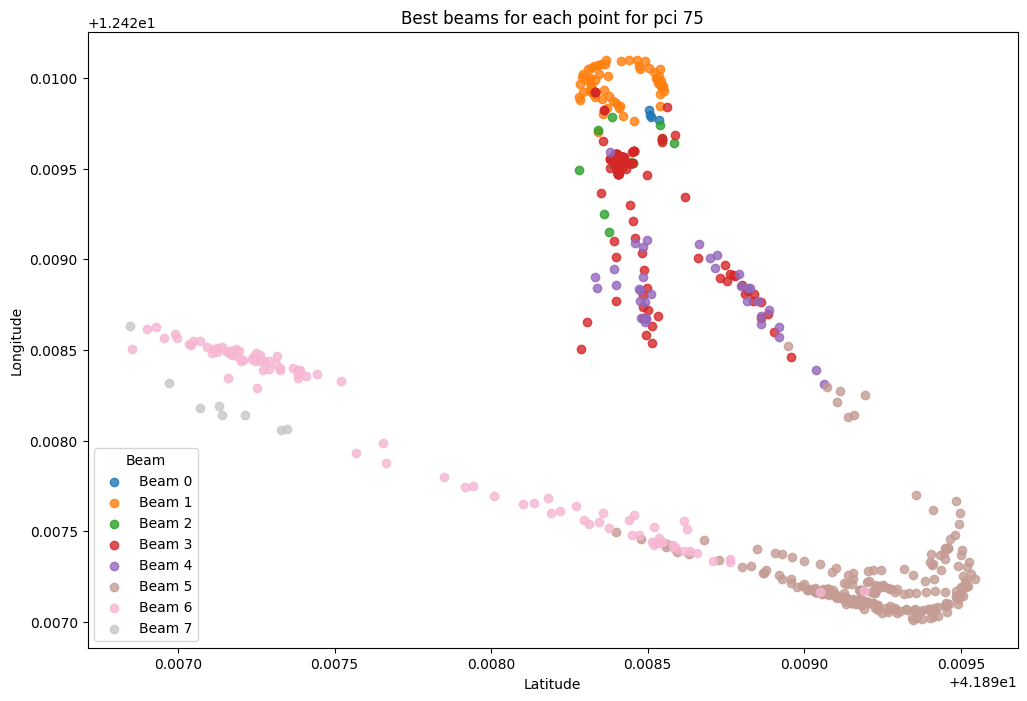

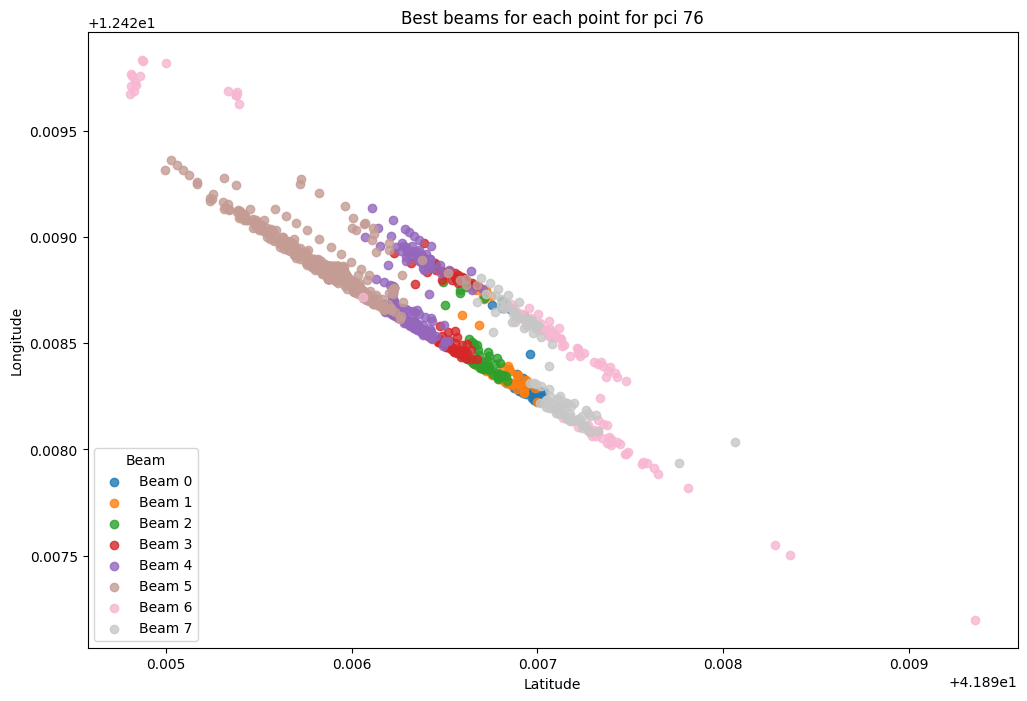

Skipping pci 121


In [4]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Use a discrete colormap with enough distinct colors
def plot_beams(df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(12, 8))
    unique_beams = np.unique(df['beam_index'])

    cmap = plt.get_cmap("tab20", 10)  # 'tab20' provides 20 distinct colors

    # Map each unique value to a color
    color_map = {val: cmap(i) for i, val in enumerate(unique_beams)}

    for beam, group in df.groupby('beam_index'):
        plt.scatter(
            group["lat"],
            group["lng"],
            color=color_map[beam],
            label=f"Beam {beam}",
            alpha=0.8,
        )

    plt.xlabel("Latitude")
    plt.ylabel("Longitude")
    plt.title(title)
    plt.legend(title="Beam", loc="lower left")
    plt.show()


def geo_plot_points(df: pd.DataFrame, title: str) -> None:
    """
    Plots given locations to a map (OpenStreetMap) that is viewable in broswer.
    Generates a file called 'map.html' in the current working directory.
    :param df:
    """
    # Create a map centered around the mean location
    m = folium.Map(location=[df["lat"].mean(), df["lng"].mean()], zoom_start=12)

    unique_beams = np.unique(df['beam_index'])

    cmap = plt.get_cmap("tab20", 10)  # 'tab20' provides 20 distinct colors
    color_map = {val: mcolors.to_hex(cmap(i)) for i, val in enumerate(unique_beams)}

    for beam, group in df.groupby('beam_index'):
        # Add CircleMarkers to the map
        for _, row in group.iterrows():
            folium.CircleMarker(
                location=[row["lat"], row["lng"]],
                radius=5,  # Size of the marker
                color=color_map[beam],
                fill=True,
                fill_color=color_map[beam],
                fill_opacity=0.6,
            ).add_to(m)

    # Save the map as an HTML file and open it in the browser
    m.save(f"{title}.html")


for pci, group in data_df.groupby('pci'):
    if len(group) < 100:
        print("Skipping pci", pci)
        continue

    plot_beams(group, title=f"Best beams for each point for pci {pci}")
    #geo_plot_points(group, title=f"Best beams for pci {pci}")


In [7]:
filtered_df.iloc[4]['measurements_matrix']['beam_index'].value_counts()

beam_index
3    12
6     8
0     7
1     7
2     7
5     7
7     7
4     6
Name: count, dtype: int64